In [2]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


In [5]:
d1,u1,m1,n1 = hf.LAPS_train("DATA",2017,Mjj_cut=800,pt_cut=300,num_ev=1000000,sideband=True)

In [6]:
d2,u2,m2,n2 = hf.LAPS_train("DATA",2017,Mjj_cut=800,pt_cut=300,num_ev=1000000,sideband=False)

In [7]:
d3,u3,m3,n3 = hf.LAPS_train("QCDBKG",2017,num_batches=5,Mjj_cut=800,pt_cut=300)

In [8]:
d1_m = np.mean(d1,axis=0)
d1_sd = np.std(d1,axis=0)
d2_m = np.mean(d2,axis=0)
d2_sd = np.std(d2,axis=0)

In [9]:
d1_n1 = (d1-d1_m)/d1_sd
d2_n2 = (d2-d2_m)/d2_sd
d3_n1 = (d3-d1_m)/d1_sd
d3_n2 = (d3-d2_m)/d2_sd

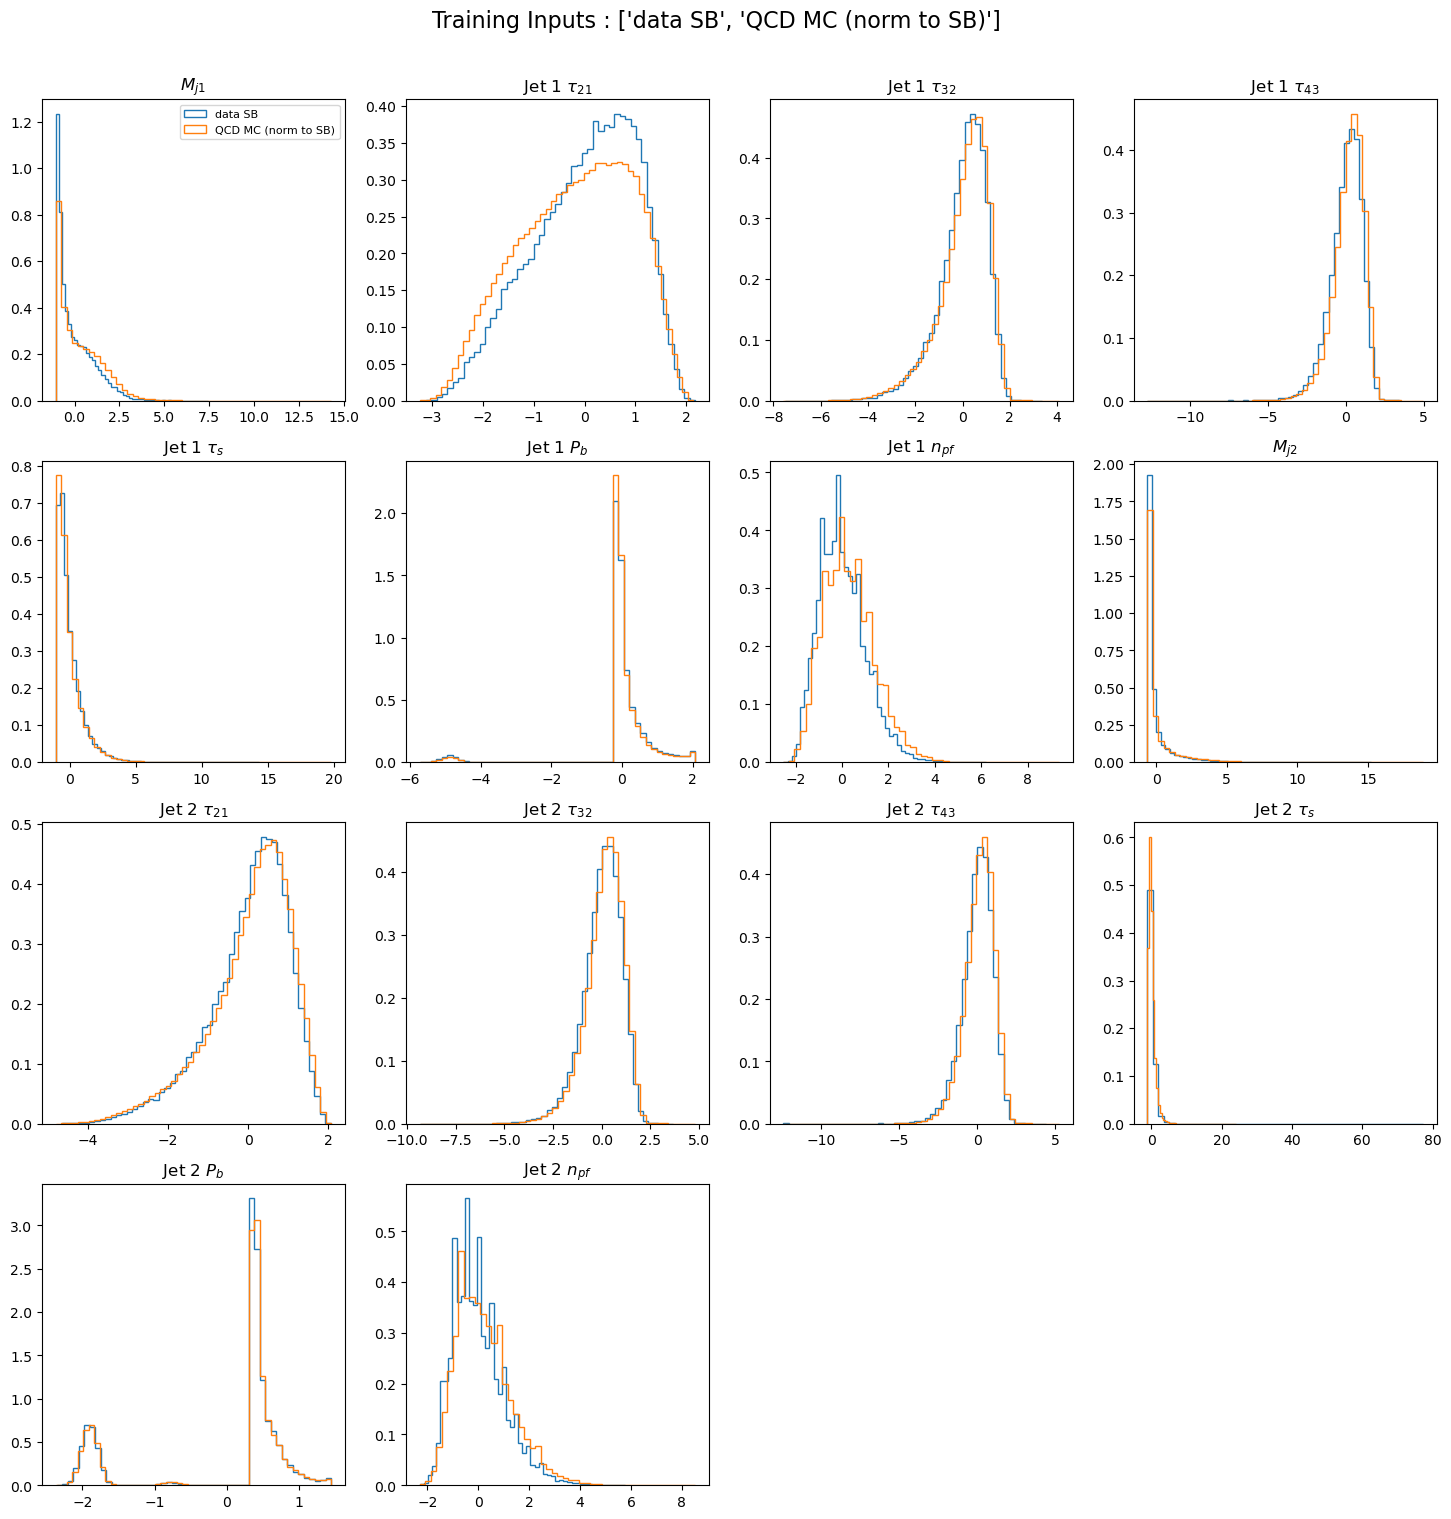

In [10]:
hf.plot_input_variables([d1_n1,d3_n1],["data SB","QCD MC (norm to SB)"],n1,save=False)

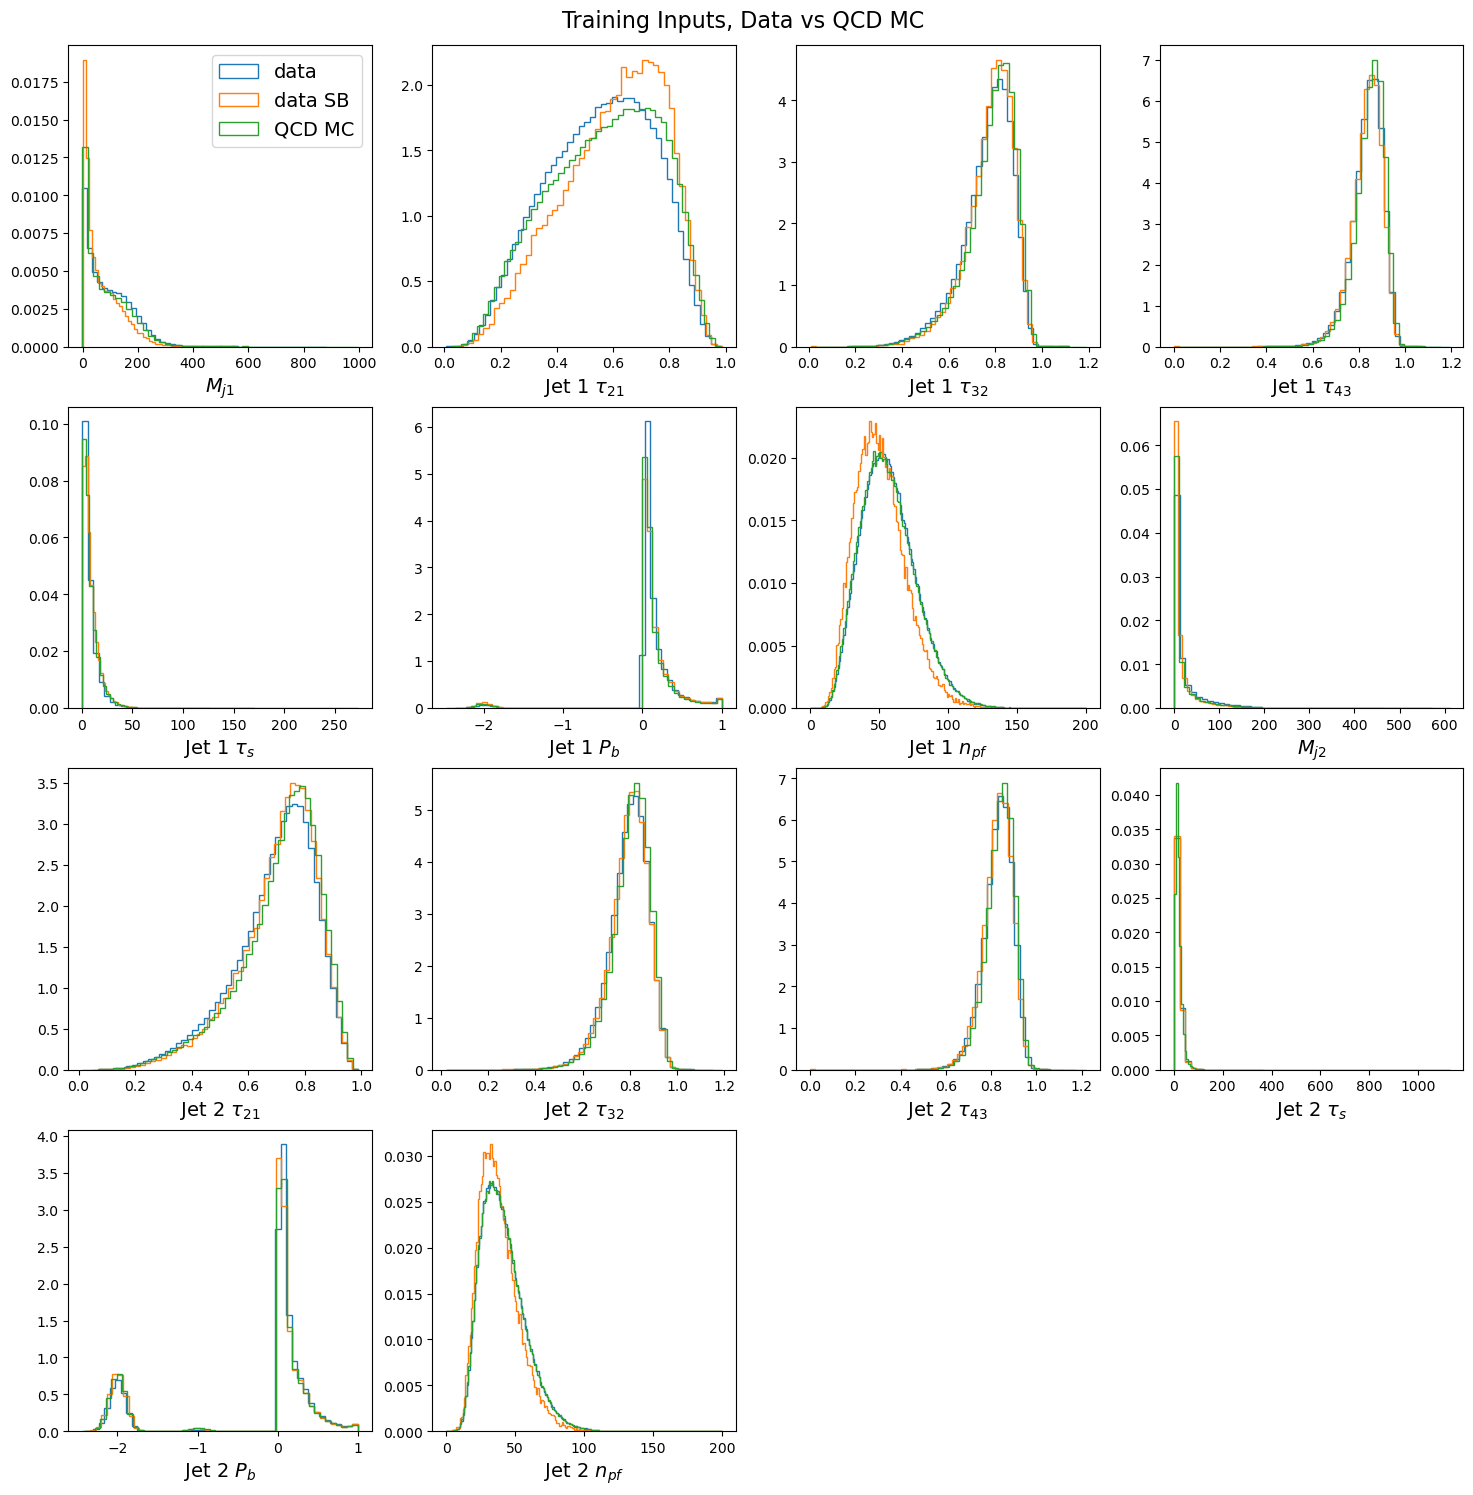

In [24]:
hf.plot_input_variables([d2,d1,d3],["data","data SB","QCD MC"],n1,save=False,log=False)
plt.suptitle("Training Inputs, Data vs QCD MC",fontsize=16,y=0.9)
#plt.tight_layout()
plt.savefig("QCD_vs_data.pdf")

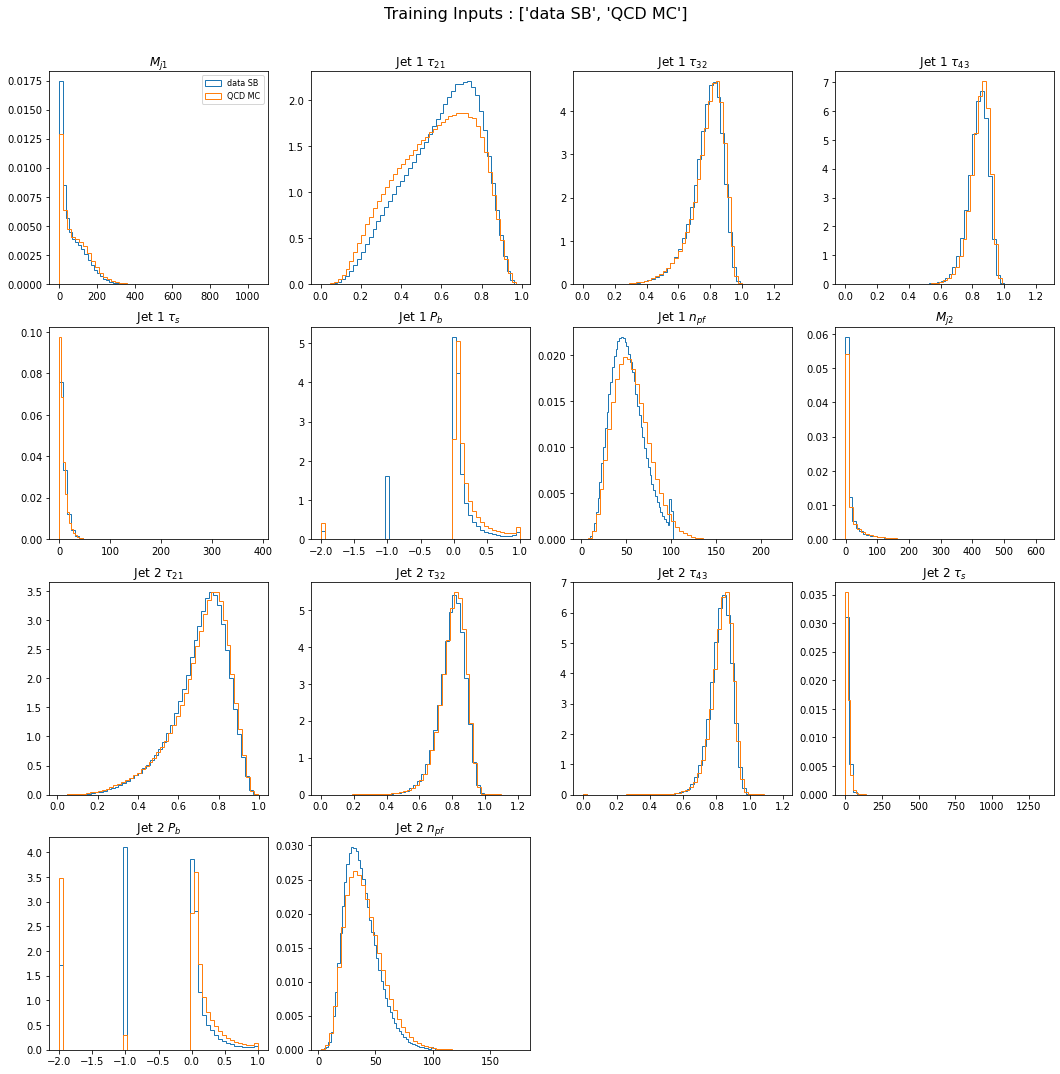

In [8]:
hf.plot_input_variables([d1,d3],["data SB","QCD MC"],n1,save=False)
plt.savefig("QCD_vs_dataSB.pdf")

In [ ]:
hf.plot_input_variables([d2,d3],["data","QCD MC"],n1,save=False)

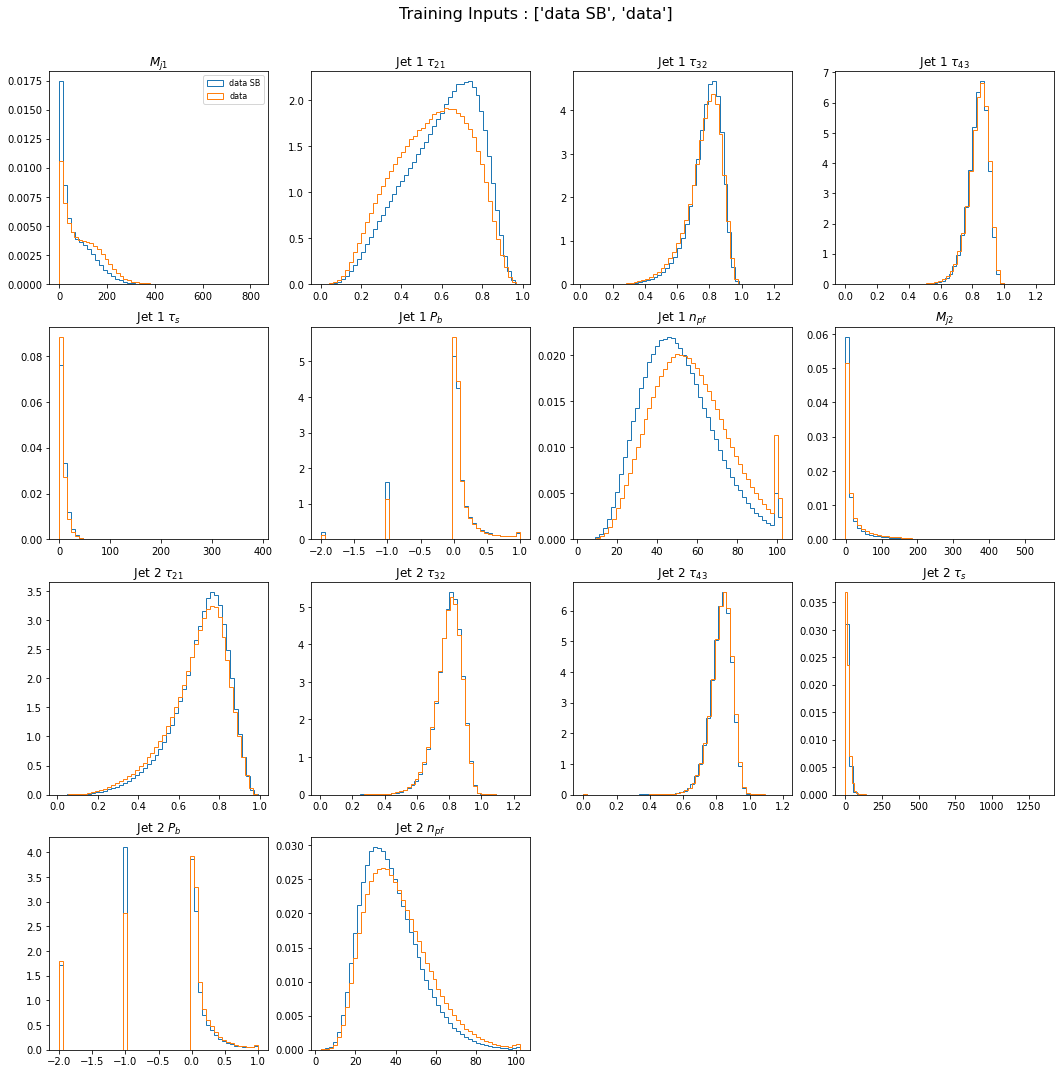

In [28]:
hf.plot_input_variables([d1,d2],["data SB","data"],n1,save=False)